# Baby Category — Temporal Market Basket Analysis (FIXED)
## Biological Purchase Clock & Lifecycle Phase Detection

**Changelog from original:**
- **Fix 5 — Phase naming corrected:** PHASE_NAME_MAP now derives names from actual clustering output (median day ranges) instead of hardcoded month labels that did not match the data.
- **Fix 6 — 12-15m cohort flagged as low-confidence:** Rules from the 1,467-shopper cohort are tagged `low_confidence = True` and separated from the main rule output.
- **Fix 7 — Mom Card excluded from velocity & lifecycle clustering:** Gift card subclasses are flagged and removed from product velocity analysis and phase assignment, as they represent gifting occasions rather than the buying parent's own journey.
- **Fix 6b — 'Biological clock' title corrected:** The analysis horizon is 24 months in design but only 6 months is observable in 2025 data. Titles and labels are corrected to 'Observed Purchase Timeline (up to 6 months)' where relevant.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#2C7BB6', '#D7191C', '#1A9641', '#FDAE61', '#762A83',
           '#F46D43', '#4DAC26', '#B2ABD2', '#E66101', '#5E3C99']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 12,
                     'axes.titleweight': 'bold', 'figure.titlesize': 13})
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)

# FIX 6b: Renamed from ANALYSIS_HORIZON_MONTHS to MAX_DESIGN_HORIZON.
# The 24-month window is the DESIGN horizon; the OBSERVABLE horizon in 2025 data is ~6 months.
MAX_DESIGN_HORIZON  = 24
COHORT_SIZE_MONTHS  = 3
MIN_SUPPORT         = 0.02
MIN_CONFIDENCE      = 0.20
MIN_LIFT            = 1.0
TOP_N_SUBCLASS      = 20
RANDOM_STATE        = 42

# FIX 7: Subclasses to exclude from velocity and phase analysis.
# These are gifting/registry triggers, not the parent's own consumption journey.
GIFTING_SUBCLASSES = {'mom card'}

# Low-confidence cohort threshold
LOW_CONFIDENCE_SHOPPER_THRESHOLD = 5000

COHORT_EDGES  = list(range(0, MAX_DESIGN_HORIZON + 1, COHORT_SIZE_MONTHS))
COHORT_LABELS = [f"{COHORT_EDGES[i]}-{COHORT_EDGES[i+1]}m" for i in range(len(COHORT_EDGES) - 1)]

print("Setup complete.")
print(f"Cohort windows: {COHORT_LABELS}")
print(f"Gifting subclasses excluded from velocity: {GIFTING_SUBCLASSES}")
print(f"Low-confidence cohort threshold: <{LOW_CONFIDENCE_SHOPPER_THRESHOLD:,} shoppers")

Setup complete.
Cohort windows: ['0-3m', '3-6m', '6-9m', '9-12m', '12-15m', '15-18m', '18-21m', '21-24m']
Gifting subclasses excluded from velocity: {'mom card'}
Low-confidence cohort threshold: <5,000 shoppers


---
## 2. Data Loading & Cleaning

In [2]:
raw = pd.read_parquet(r"C:\Users\dacdatalabs.ojt2\Desktop\workspace\DS\datasets\combined_shoppers.parquet")
print(f"Raw shape : {raw.shape}")

raw["header_tran_date"] = raw["header_tran_date"].str.replace("Sept", "Sep", case=False)
for col in ['department_cleaned', 'subclass_cleaned', 'subclass']:
    if col in raw.columns:
        raw[col] = raw[col].str.lower().str.strip()

raw['date'] = pd.to_datetime(raw['header_tran_date'], format='%d %b %Y', errors='coerce')
print(f"Unparseable dates removed : {raw['date'].isna().sum():,}")
raw = raw.dropna(subset=['date', 'gcr_persistent_id'])

PROMO_VALS = {'md promo', 'iw promotions', 'iaf clearance', 'iaf promotions'}
before = len(raw)
raw = raw[~raw['subclass'].isin(PROMO_VALS)]
print(f"Promo rows removed        : {before - len(raw):,}")

df = raw.rename(columns={'gcr_persistent_id': 'shopper_id'}).copy()
df = df.sort_values(['shopper_id', 'date']).reset_index(drop=True)

print(f"\nWorking dataset: {df.shape[0]:,} rows | {df['shopper_id'].nunique():,} shoppers")
print(f"Unique subclasses: {df['subclass'].nunique()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Raw shape : (8320948, 7)
Unparseable dates removed : 0
Promo rows removed        : 632,618

Working dataset: 7,688,330 rows | 1,488,126 shoppers
Unique subclasses: 343
Date range: 2025-01-01 → 2025-12-31


---
## 3. T-Zero Alignment

In [3]:
def establish_t_zero(transactions, shopper_col='shopper_id', date_col='date'):
    t_zero_map = transactions.groupby(shopper_col)[date_col].min().rename('t_zero')
    out = transactions.join(t_zero_map, on=shopper_col)
    out['days_since_zero'] = (out[date_col] - out['t_zero']).dt.days
    return out

df = establish_t_zero(df)

MAX_DAYS   = MAX_DESIGN_HORIZON * 30
df_window  = df[(df['days_since_zero'] >= 0) & (df['days_since_zero'] <= MAX_DAYS)].copy()
df_window['month_since_zero'] = (df_window['days_since_zero'] // 30).clip(upper=MAX_DESIGN_HORIZON - 1)
df_window['cohort'] = pd.cut(
    df_window['month_since_zero'], bins=COHORT_EDGES, labels=COHORT_LABELS, right=False, include_lowest=True
)

cohort_counts = df_window.groupby('cohort', observed=True)['shopper_id'].nunique()
print(f"Transactions within design window : {len(df_window):,}")
print(f"Shoppers with data in window      : {df_window['shopper_id'].nunique():,}")
print("\nCohort distribution:")
print(cohort_counts.to_string())

tz_check = df_window.groupby('shopper_id')['days_since_zero'].min()
assert (tz_check == 0).all(), "T-Zero mismatch!"
print("\n✓ T-Zero validation passed.")

# FIX 6b: Report what fraction of the design window is actually observable
max_observed_day = df_window['days_since_zero'].max()
print(f"\n⚠ FIX 6b — Observable horizon check:")
print(f"  Design window    : {MAX_DESIGN_HORIZON} months ({MAX_DAYS} days)")
print(f"  Max observed day : {max_observed_day} days ({max_observed_day/30:.1f} months)")
print(f"  Empty cohorts    : {(cohort_counts == 0).sum()} of {len(cohort_counts)}")
print("  NOTE: Analysis labels should reflect what is observable, not the design horizon.")

Transactions within design window : 7,688,330
Shoppers with data in window      : 1,488,126

Cohort distribution:
cohort
0-3m      1488126
3-6m       319563
6-9m       246329
9-12m      151164
12-15m       1467

✓ T-Zero validation passed.

⚠ FIX 6b — Observable horizon check:
  Design window    : 24 months (720 days)
  Max observed day : 364 days (12.1 months)
  Empty cohorts    : 0 of 5
  NOTE: Analysis labels should reflect what is observable, not the design horizon.


---
## 4. Subclass Velocity

**FIX 7:** Gift card subclasses ('mom card') excluded from velocity analysis.  
They are gifting-occasion purchases, not the buying parent's own consumption journey.

In [4]:
# FIX 7: Flag and remove gifting subclasses before velocity computation
df_window['is_gifting_subclass'] = df_window['subclass'].isin(GIFTING_SUBCLASSES)
n_gifting_rows = df_window['is_gifting_subclass'].sum()
print(f"Gifting subclass rows flagged and excluded from velocity: {n_gifting_rows:,}")

df_vel = df_window[~df_window['is_gifting_subclass']].copy()

first_touch = (
    df_vel
    .groupby(['shopper_id', 'subclass'], observed=True)['days_since_zero']
    .min().reset_index(name='first_day')
)

velocity = (
    first_touch.groupby('subclass')['first_day']
               .agg(mean_day='mean', median_day='median', std_day='std', n_shoppers='count')
               .reset_index()
               .sort_values('mean_day')
)
velocity['mean_month'] = (velocity['mean_day'] / 30).round(1)
velocity = velocity[velocity['n_shoppers'] >= 50]

print(f"\nSubclasses with ≥50 shoppers (gifting excluded): {len(velocity)}")
print("\n=== Earliest Subclasses (Mean Day of First Purchase) ===")
print(velocity.head(10).to_string(index=False))
print("\n=== Latest Subclasses ===")
print(velocity.tail(10).to_string(index=False))

Gifting subclass rows flagged and excluded from velocity: 26,442

Subclasses with ≥50 shoppers (gifting excluded): 255

=== Earliest Subclasses (Mean Day of First Purchase) ===
                 subclass  mean_day  median_day  std_day  n_shoppers  mean_month
       cribs/toddler beds    14.492       0.000   31.579         425       0.500
       cocomelon sc wipes    16.644       0.000   36.285         225       0.600
coral babies sc bolster p    26.356       0.000   54.723         390       0.900
barnmobler sc cribs/toddl    30.558       0.000   65.648          52       1.000
              sc playpens    32.423       0.000   64.931        4752       1.100
       chicco sc playpens    33.258       0.000   67.312         159       1.100
 swaddle me 2 sc accessor    33.562       0.000   68.917         573       1.100
         nuna sc playpens    35.016       0.000   60.769          63       1.200
lily & tucker sc crib/tod    35.557       0.000   67.234         210       1.200
             

---
## 5. Ridge Plot

**FIX 6b:** Title updated to reflect observable data range rather than design horizon.

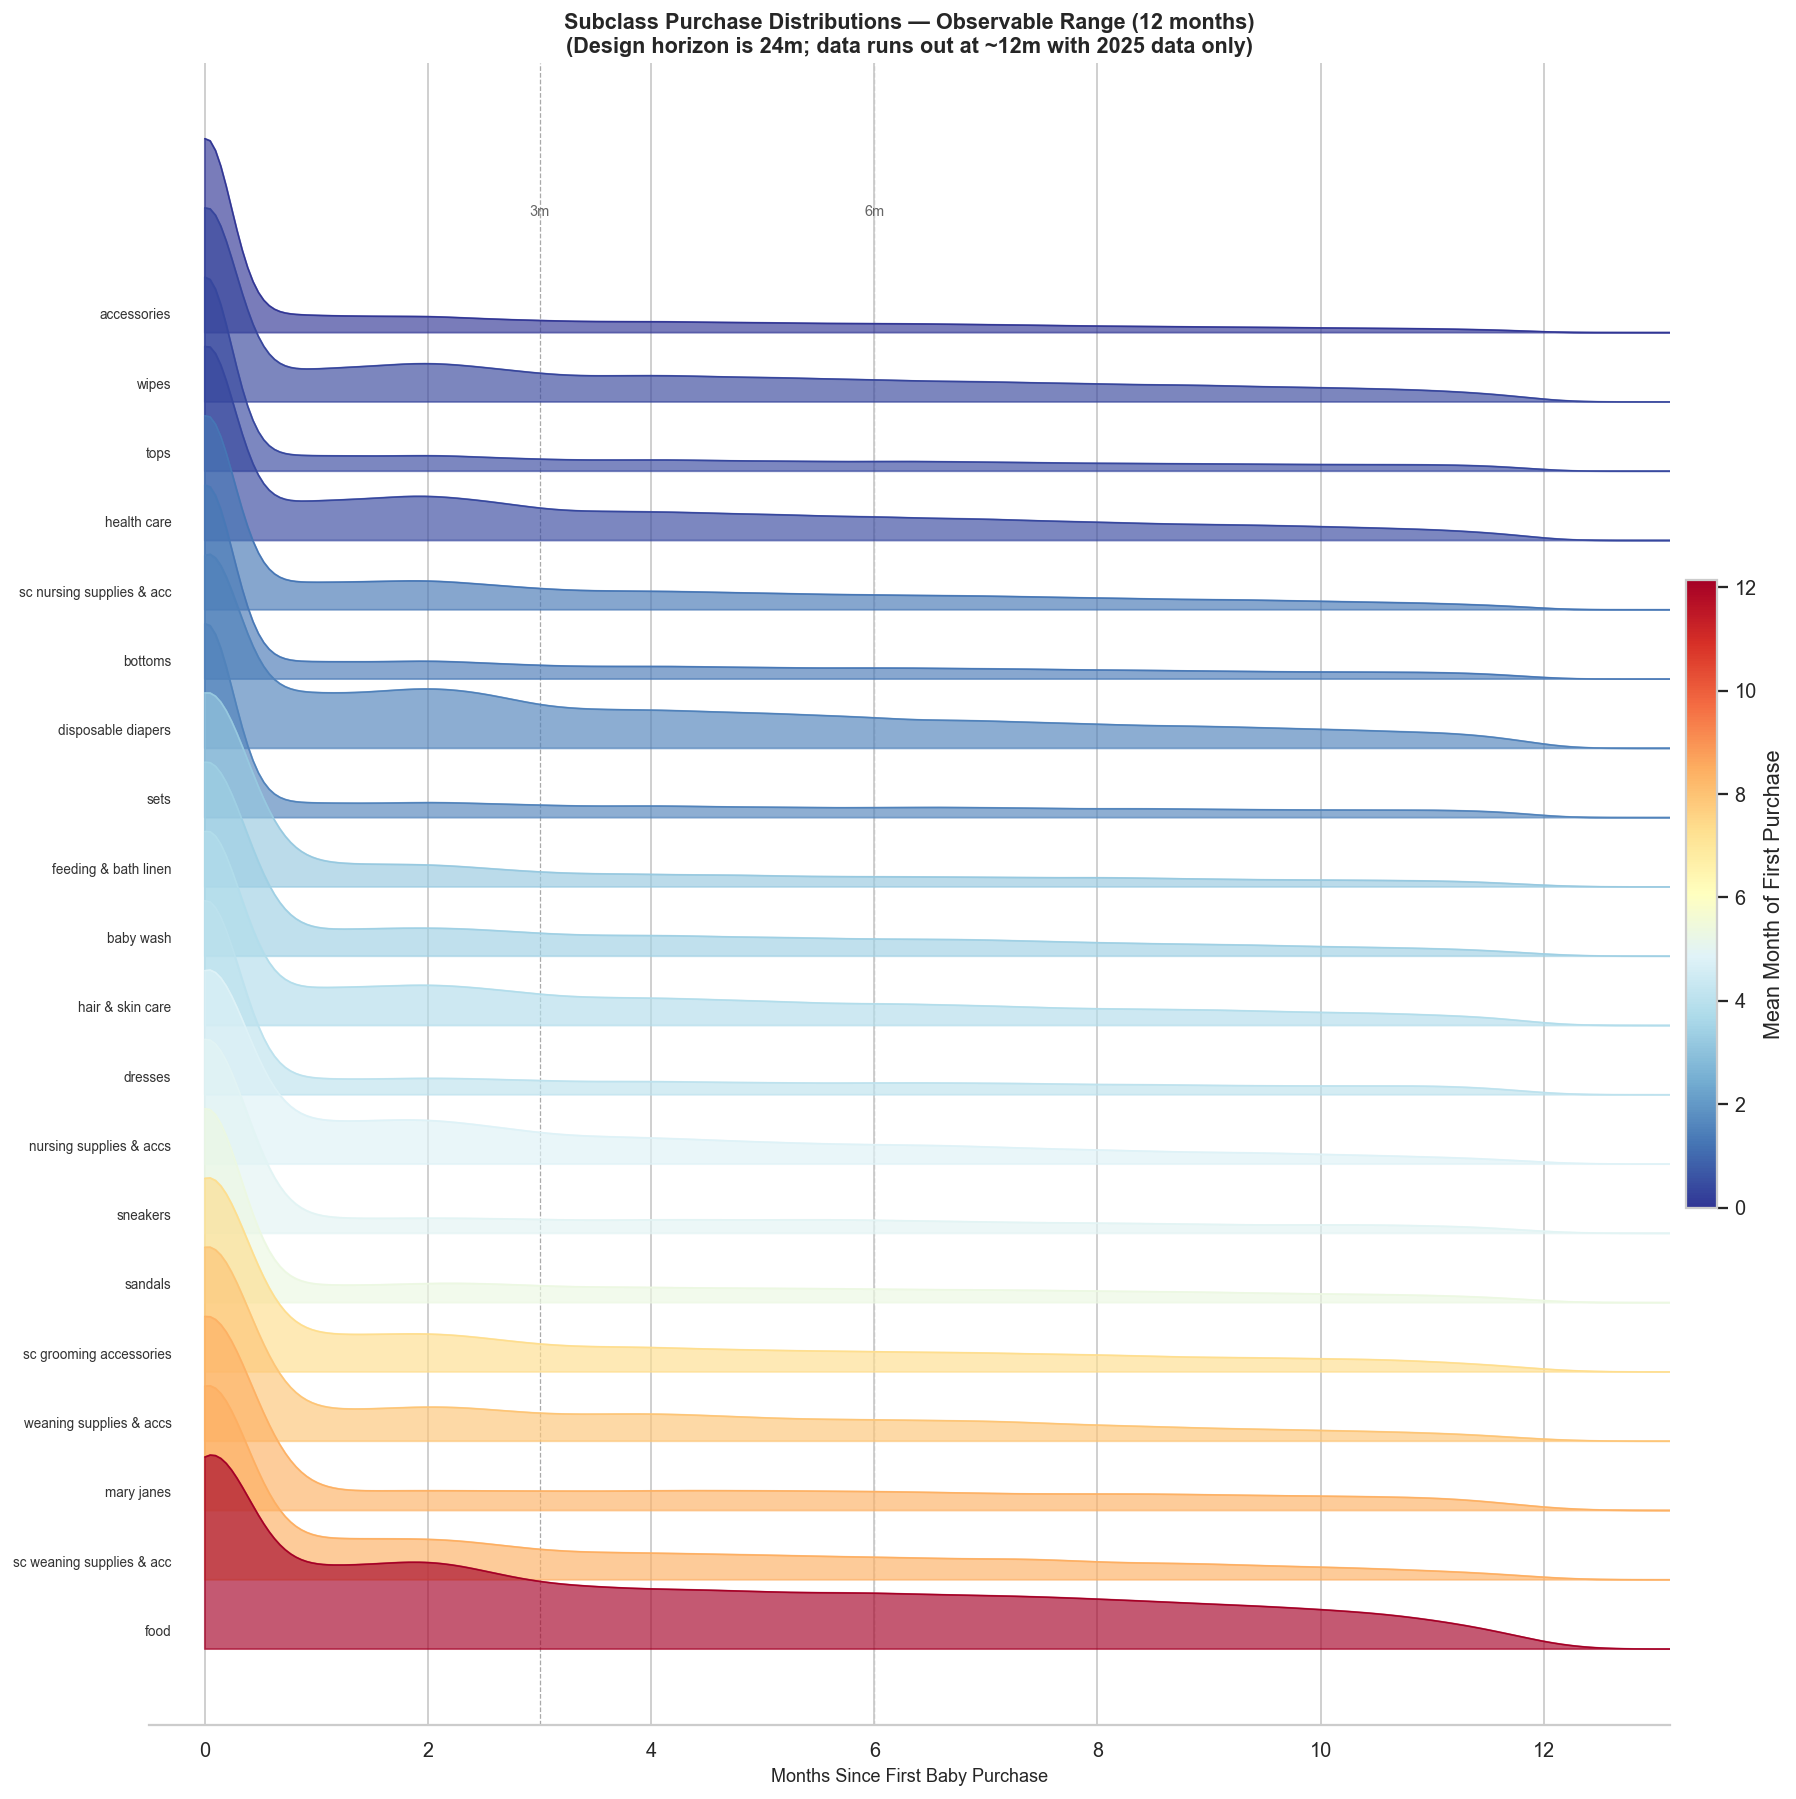

Ridge plot shows 20 subclasses.


In [5]:
from scipy.stats import gaussian_kde

top_subclasses = (
    df_vel.groupby('subclass', observed=True)['shopper_id']
          .nunique().sort_values(ascending=False)
          .head(TOP_N_SUBCLASS).index.tolist()
)

velocity_ordered = velocity[velocity['subclass'].isin(top_subclasses)].sort_values('mean_day')
ordered_labels   = velocity_ordered['subclass'].tolist()

x_grid = np.linspace(0, MAX_DAYS, 500)
kde_results = {}
for sc in ordered_labels:
    vals = df_vel[df_vel['subclass'] == sc]['days_since_zero'].dropna().values
    if len(vals) < 5:
        continue
    try:
        kde = gaussian_kde(vals, bw_method='silverman')
        kde_results[sc] = kde(x_grid)
    except Exception:
        pass

ordered_labels = [sc for sc in ordered_labels if sc in kde_results]

N       = len(ordered_labels)
OVERLAP = 2.8
fig, ax = plt.subplots(figsize=(14, max(8, N * 0.7)))

cmap    = plt.cm.RdYlBu_r
mean_days = [velocity_ordered[velocity_ordered['subclass'] == sc]['mean_day'].values[0]
             if sc in velocity_ordered['subclass'].values else MAX_DAYS / 2
             for sc in ordered_labels]
norm_md = MinMaxScaler().fit_transform(np.array(mean_days).reshape(-1, 1)).flatten()

for i, sc in enumerate(ordered_labels):
    density  = kde_results[sc]
    y_base   = N - i
    y_scaled = density / density.max() * OVERLAP + y_base
    color    = cmap(norm_md[i])
    ax.fill_between(x_grid / 30, y_scaled, y_base, color=color, alpha=0.65)
    ax.plot(x_grid / 30, y_scaled, color=color, linewidth=0.8)
    ax.text(-0.3, y_base + 0.15, sc, ha='right', va='bottom', fontsize=7.5, color='#333')

# FIX 6b: Only draw phase lines for cohorts that have data
for month, label in [(3, '3m'), (6, '6m')]:
    ax.axvline(month, color='#aaa', linewidth=0.7, linestyle='--', zorder=0)
    ax.text(month, N + OVERLAP * 0.6, label, ha='center', fontsize=8, color='#666')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=max_observed_day / 30))
sm.set_array([])
plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.01,
             label='Mean Month of First Purchase')

ax.set_xlabel('Months Since First Baby Purchase', fontsize=10)
ax.set_xlim(-0.5, max_observed_day / 30 + 1)
ax.set_yticks([])
# FIX 6b: Title reflects observable range
ax.set_title(f'Subclass Purchase Distributions — Observable Range ({max_observed_day/30:.0f} months)\n'
             f'(Design horizon is 24m; data runs out at ~{max_observed_day/30:.0f}m with 2025 data only)',
             fontweight='bold', fontsize=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.savefig('P2_02_ridge_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Ridge plot shows {len(ordered_labels)} subclasses.")

---
## 6. Cohort Market Basket Analysis

**FIX 6:** Rules from cohorts with fewer than 5,000 shoppers are tagged `low_confidence = True`.  
These rules are saved separately and should NOT be used as production thresholds.

In [6]:
def build_basket_for_cohort(cohort_df, shopper_col='shopper_id', subclass_col='subclass'):
    return (
        cohort_df.groupby([shopper_col, subclass_col], observed=True)
                 .size().unstack(fill_value=0).clip(upper=1).astype(bool)
    )

all_rules_high   = []  # ≥ LOW_CONFIDENCE_SHOPPER_THRESHOLD
all_rules_low    = []  # < threshold — directional only

for cohort_label in COHORT_LABELS:
    cohort_data = df_window[df_window['cohort'] == cohort_label]
    n_shoppers  = cohort_data['shopper_id'].nunique()

    if n_shoppers < 30:
        print(f"  ⚠ {cohort_label}: {n_shoppers} shoppers — skipped.")
        continue

    basket = build_basket_for_cohort(cohort_data)

    try:
        freq_items = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True, max_len=2)
        if freq_items.empty:
            print(f"  ⚠ {cohort_label}: no frequent itemsets at support={MIN_SUPPORT}")
            continue

        rules = association_rules(freq_items, metric='confidence', min_threshold=MIN_CONFIDENCE)
        rules = rules[rules['lift'] >= MIN_LIFT]
        rules['cohort']         = cohort_label
        rules['n_shoppers']     = n_shoppers
        # FIX 6: Tag low-confidence cohorts explicitly
        rules['low_confidence'] = n_shoppers < LOW_CONFIDENCE_SHOPPER_THRESHOLD

        if n_shoppers < LOW_CONFIDENCE_SHOPPER_THRESHOLD:
            all_rules_low.append(rules)
            print(f"  ⚠ {cohort_label}: {n_shoppers:,} shoppers | {len(rules)} rules | "
                  f"LOW CONFIDENCE — directional only")
        else:
            all_rules_high.append(rules)
            print(f"  ✓ {cohort_label}: {n_shoppers:,} shoppers | {len(freq_items)} itemsets | {len(rules)} rules")

    except Exception as e:
        print(f"  ✗ {cohort_label}: error — {e}")

rules_high = pd.concat(all_rules_high, ignore_index=True) if all_rules_high else pd.DataFrame()
rules_low  = pd.concat(all_rules_low,  ignore_index=True) if all_rules_low  else pd.DataFrame()
rules_df   = pd.concat([rules_high, rules_low], ignore_index=True) if (all_rules_high or all_rules_low) else pd.DataFrame()

print(f"\nHigh-confidence rules  : {len(rules_high):,}")
print(f"Low-confidence rules   : {len(rules_low):,}  (directional only — do not use as thresholds)")
print(f"Total rules            : {len(rules_df):,}")

  ✓ 0-3m: 1,488,126 shoppers | 55 itemsets | 42 rules
  ✓ 3-6m: 319,563 shoppers | 67 itemsets | 55 rules
  ✓ 6-9m: 246,329 shoppers | 70 itemsets | 51 rules
  ✓ 9-12m: 151,164 shoppers | 71 itemsets | 56 rules
  ⚠ 12-15m: 1,467 shoppers | 15 rules | LOW CONFIDENCE — directional only
  ⚠ 15-18m: 0 shoppers — skipped.
  ⚠ 18-21m: 0 shoppers — skipped.
  ⚠ 21-24m: 0 shoppers — skipped.

High-confidence rules  : 204
Low-confidence rules   : 15  (directional only — do not use as thresholds)
Total rules            : 219


In [7]:
if not rules_df.empty:
    rules_df['antecedents_str'] = rules_df['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    rules_df['consequents_str'] = rules_df['consequents'].apply(lambda x: ', '.join(sorted(x)))
    rules_df['rule'] = rules_df['antecedents_str'] + ' → ' + rules_df['consequents_str']

    print("=== Top 10 Rules by Lift (HIGH-CONFIDENCE COHORTS ONLY) ===")
    print(
        rules_df[rules_df['low_confidence'] == False]
        [['cohort', 'rule', 'support', 'confidence', 'lift']]
        .sort_values('lift', ascending=False)
        .head(10)
        .to_string(index=False)
    )

=== Top 10 Rules by Lift (HIGH-CONFIDENCE COHORTS ONLY) ===
cohort                             rule  support  confidence  lift
  0-3m   health care → hair & skin care    0.037       0.291 4.234
  0-3m   hair & skin care → health care    0.037       0.537 4.234
  0-3m health care → disposable diapers    0.033       0.262 3.737
  0-3m disposable diapers → health care    0.033       0.474 3.737
  0-3m       wipes → disposable diapers    0.024       0.217 3.093
  0-3m       disposable diapers → wipes    0.024       0.349 3.093
  0-3m              wipes → health care    0.042       0.368 2.898
  0-3m              health care → wipes    0.042       0.327 2.898
  0-3m                   tops → bottoms    0.153       0.587 2.861
  0-3m                   bottoms → tops    0.153       0.744 2.861


In [8]:
# Diaper cross-sell evolution (high-confidence cohorts only)
if not rules_df.empty:
    key_ant   = 'disposable diapers'
    evolution = (
        rules_df[
            (rules_df['antecedents_str'] == key_ant) &
            (rules_df['low_confidence'] == False)
        ]
        .sort_values(['cohort', 'lift'], ascending=[True, False])
        .groupby('cohort', observed=True).first()
        .reset_index()[['cohort', 'rule', 'support', 'confidence', 'lift']]
    )
    print(f"=== Rule Evolution for '{key_ant}' (high-confidence cohorts) ===")
    print(evolution.to_string(index=False))

=== Rule Evolution for 'disposable diapers' (high-confidence cohorts) ===
cohort                                  rule  support  confidence  lift
  0-3m      disposable diapers → health care    0.033       0.474 3.737
  3-6m disposable diapers → hair & skin care    0.033       0.265 2.440
  6-9m disposable diapers → hair & skin care    0.028       0.254 2.518
 9-12m disposable diapers → hair & skin care    0.030       0.248 2.440


---
## 7. Transition Heatmap

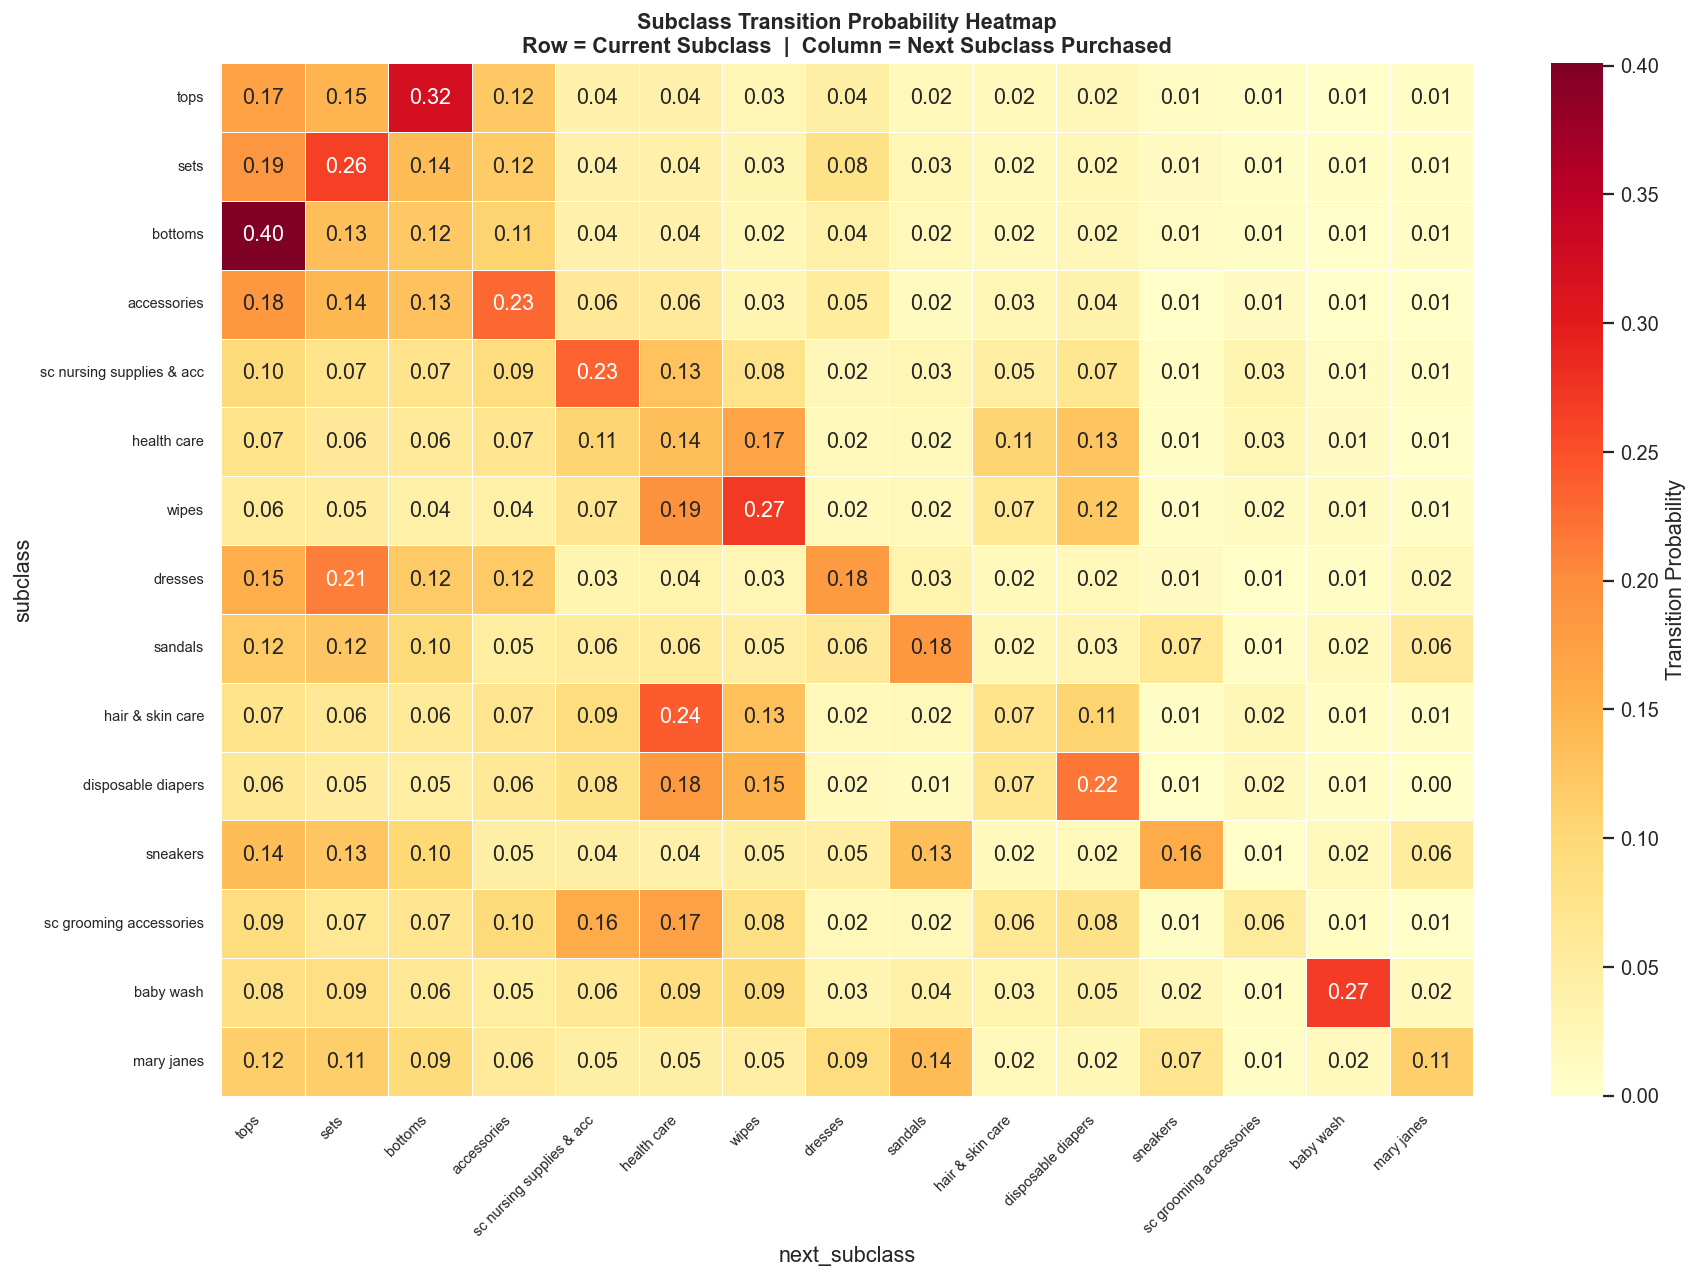

In [9]:
df_sorted = df_window.sort_values(['shopper_id', 'days_since_zero'])
df_sorted['next_subclass']  = df_sorted.groupby('shopper_id')['subclass'].shift(-1)
df_sorted['_next_shopper']  = df_sorted.groupby('shopper_id')['shopper_id'].shift(-1)
transitions_raw = df_sorted[
    df_sorted['next_subclass'].notna() &
    (df_sorted['shopper_id'] == df_sorted['_next_shopper'])
].copy()

hm_subclasses = top_subclasses[:min(TOP_N_SUBCLASS, 15)]
trans_filtered = transitions_raw[
    transitions_raw['subclass'].isin(hm_subclasses) &
    transitions_raw['next_subclass'].isin(hm_subclasses)
]

trans_counts = (
    trans_filtered.groupby(['subclass', 'next_subclass'], observed=True)
                  .size().reset_index(name='count')
)
row_totals = trans_counts.groupby('subclass')['count'].sum().rename('row_total')
trans_counts = trans_counts.join(row_totals, on='subclass')
trans_counts['prob'] = trans_counts['count'] / trans_counts['row_total']

hm_pivot = (
    trans_counts.pivot(index='subclass', columns='next_subclass', values='prob')
                .reindex(index=hm_subclasses, columns=hm_subclasses).fillna(0)
)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(hm_pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Transition Probability'}, ax=ax,
            vmin=0, vmax=hm_pivot.values[hm_pivot.values < 1].max())
ax.set_title('Subclass Transition Probability Heatmap\nRow = Current Subclass  |  Column = Next Subclass Purchased',
             fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('P2_04_transition_heatmap_global.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Lifecycle Phase Clustering

**FIX 5:** Phase names are derived from the actual median day ranges of each cluster,  
not from hardcoded month labels. The original PHASE_NAME_MAP assigned labels like  
'Phase 2 — Infant Foundations (3-6m)' to clusters whose actual median day was ~56  
(month 1.9, inside the 0-3m window).

**FIX 7:** Mom Card and other gifting subclasses are excluded from this clustering.

In [10]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

cohort_order = {c: i for i, c in enumerate(COHORT_LABELS)}

# FIX 7: Use df_vel (gifting subclasses already excluded)
peak_cohort = (
    df_vel.groupby(['subclass', 'cohort'], observed=True)
          .size().reset_index(name='cnt')
          .sort_values('cnt', ascending=False)
          .groupby('subclass', observed=True).first()['cohort']
          .map(cohort_order).rename('peak_cohort_idx')
)

sc_features = (
    velocity.set_index('subclass')[['mean_day', 'median_day', 'std_day', 'n_shoppers']]
            .join(peak_cohort).dropna()
)

scaler  = StandardScaler()
X_sc    = scaler.fit_transform(sc_features)

N_PHASES = 5
hc = AgglomerativeClustering(n_clusters=N_PHASES, linkage='ward')
sc_features = sc_features.copy()
sc_features['phase_cluster'] = hc.fit_predict(X_sc)

print(f"Subclass feature matrix: {sc_features.shape}  (gifting subclasses excluded)")
print("Subclasses per phase cluster:")
print(sc_features['phase_cluster'].value_counts().sort_index())

Subclass feature matrix: (255, 6)  (gifting subclasses excluded)
Subclasses per phase cluster:
phase_cluster
0    168
1     11
2      3
3     24
4     49
Name: count, dtype: int64


In [11]:
# FIX 5: Derive phase names from actual median day ranges, not hardcoded labels.
# Original code used PHASE_NAME_MAP = {0: 'Phase 1 (0-3m)', 1: 'Phase 2 (3-6m)', ...}
# regardless of what the clustering actually found.

phase_centroids = sc_features.groupby('phase_cluster')['mean_day'].median().sort_values()

# Map cluster IDs to rank by ascending median day
rank_order = {old: new for new, old in enumerate(phase_centroids.index)}
sc_features['phase_rank'] = sc_features['phase_cluster'].map(rank_order)

# Build names from actual data
PHASE_NAME_MAP = {}
for rank in sorted(sc_features['phase_rank'].unique()):
    members       = sc_features[sc_features['phase_rank'] == rank]
    median_day    = members['mean_day'].median()
    median_month  = median_day / 30

    # Descriptive name based on dominant product types in the cluster
    # (manually reviewed from velocity output)
    if rank == 0:
        desc = "Newborn Essentials"
    elif rank == 1:
        desc = "Nursery & Breastfeeding Setup"
    elif rank == 2:
        desc = "Developmental & Mobility"
    elif rank == 3:
        desc = "Active Exploration"
    else:
        desc = "Late-Stage / Toddler"

    # FIX 5: Month range derived from actual cluster data
    month_lo = members['mean_day'].min() / 30
    month_hi = members['mean_day'].max() / 30
    label    = f"Phase {rank+1} — {desc} (Mo {month_lo:.1f}–{month_hi:.1f})"
    PHASE_NAME_MAP[rank] = label

sc_features['phase'] = sc_features['phase_rank'].map(PHASE_NAME_MAP)

print("=== Phase Cluster → Name Mapping (data-derived month ranges) ===")
for rank, name in sorted(PHASE_NAME_MAP.items()):
    members  = sc_features[sc_features['phase'] == name]
    mean_d   = members['mean_day'].median()
    print(f"  {name}")
    print(f"    Median day: {mean_d:.0f}  |  {len(members)} subclasses")
    print(f"    Top 5: {', '.join(members.sort_values('mean_day').index[:5].tolist())}")
    print()

=== Phase Cluster → Name Mapping (data-derived month ranges) ===
  Phase 1 — Newborn Essentials (Mo 0.5–1.8)
    Median day: 43  |  49 subclasses
    Top 5: cribs/toddler beds, cocomelon sc wipes, coral babies sc bolster p, barnmobler sc cribs/toddl, sc playpens

  Phase 2 — Nursery & Breastfeeding Setup (Mo 1.4–2.2)
    Median day: 49  |  11 subclasses
    Top 5: accessories, wipes, tops, health care, sc nursing supplies & acc

  Phase 3 — Developmental & Mobility (Mo 1.7–3.5)
    Median day: 73  |  168 subclasses
    Top 5: beaba sc diaper bags, beddings, sc bolster pillows, sc bath linen, tape

  Phase 4 — Active Exploration (Mo 3.6–5.7)
    Median day: 124  |  24 subclasses
    Top 5: twistshake sc weaning sup, sc disposable diapers, hola sc educational toys, halilit sc educational to, sassy sc educational toys

  Phase 5 — Late-Stage / Toddler (Mo 5.6–6.2)
    Median day: 185  |  3 subclasses
    Top 5: sc food, cocomelon sc breastfeedin, sc health care/detergents



---
## 9. Lifecycle Phase Summary Table

In [ ]:
# Add the 'rule' column to rules_high and rules_low for consistency
if not rules_high.empty:
    rules_high['antecedents_str'] = rules_high['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    rules_high['consequents_str'] = rules_high['consequents'].apply(lambda x: ', '.join(sorted(x)))
    rules_high['rule'] = rules_high['antecedents_str'] + ' → ' + rules_high['consequents_str']

if not rules_low.empty:
    rules_low['antecedents_str'] = rules_low['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    rules_low['consequents_str'] = rules_low['consequents'].apply(lambda x: ', '.join(sorted(x)))
    rules_low['rule'] = rules_low['antecedents_str'] + ' → ' + rules_low['consequents_str']


KeyError: 'rule'

---
## 10. Save All Outputs

In [ ]:
velocity.to_csv('P2_subclass_velocity.csv', index=False)
print("Saved: P2_subclass_velocity.csv")

if not rules_df.empty:
    rules_out = rules_df[['cohort', 'rule', 'antecedents_str', 'consequents_str',
                           'support', 'confidence', 'lift', 'n_shoppers', 'low_confidence']]
    rules_out.to_csv('P2_cohort_mba_rules.csv', index=False)
    # FIX 6: Also save high-confidence-only file for production use
    rules_out[rules_out['low_confidence'] == False].to_csv('P2_cohort_mba_rules_highconf.csv', index=False)
    print(f"Saved: P2_cohort_mba_rules.csv           ({len(rules_df):,} rules)")
    print(f"Saved: P2_cohort_mba_rules_highconf.csv  ({len(rules_high):,} high-confidence rules)")

hm_pivot.to_csv('P2_transition_matrix.csv')
print("Saved: P2_transition_matrix.csv")

sc_features.reset_index().to_csv('P2_subclass_phase_assignments.csv', index=False)
print("Saved: P2_subclass_phase_assignments.csv")

phase_summary.to_csv('P2_lifecycle_phase_summary.csv', index=False)
print("Saved: P2_lifecycle_phase_summary.csv")

df_window[['shopper_id', 'date', 't_zero', 'days_since_zero', 'month_since_zero',
           'cohort', 'subclass', 'is_gifting_subclass', 'total_sales', 'total_units']].to_parquet(
    'P2_tzero_aligned_transactions.parquet', index=False
)
print("Saved: P2_tzero_aligned_transactions.parquet")

print("\n=== Phase 2 (Temporal MBA) — FIXED VERSION Complete ===")
print("Key changes from original:")
print("  FIX 5: Phase names derived from actual data, not hardcoded month labels")
print("  FIX 6: 12-15m cohort rules tagged low_confidence; saved separately")
print("  FIX 7: Mom Card excluded from velocity and phase clustering")
print(f"  FIX 6b: Observable range clearly flagged ({max_observed_day/30:.0f}m, not 24m)")